In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [2]:
def avaliar_modelo(modelo, X_treino, y_treino, X_teste, y_teste, nome="Modelo"):
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)

    report_dict = classification_report(y_teste, y_pred, output_dict=True)
    df = pd.DataFrame(report_dict).transpose()
    df = df.round(2)
    df.rename(index={
    "0.0": "DN",
    "1.0": "DP"
    }, inplace=True)

    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis('off')
    tbl = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, loc='center', cellLoc='center')
    tbl.scale(1.2, 1.5)
    plt.title(f"Resultados - {nome}", fontsize=12)
    plt.tight_layout()
    plt.show()


    cm = confusion_matrix(y_teste, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    if hasattr(modelo, "feature_importances_"):
        importancias = pd.Series(modelo.feature_importances_, index=X_treino.columns)
        top_importantes = importancias.sort_values(ascending=False).head(20)

        plt.figure(figsize=(8, 6))
        top_importantes.plot(kind="barh")
        plt.title(f"20 Variáveis Mais Relevantes - {nome}")
        plt.xlabel("Importância")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    return modelo, y_pred


In [3]:
def extrair_metricas(y_verdadeiro, y_predito, nome="Modelo"):
    report = classification_report(y_verdadeiro, y_predito, output_dict=True,digits=3)
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_verdadeiro, y_predito),
        "0_Precision": report["0.0"]["precision"],
        "0_Recall": report["0.0"]["recall"],
        "0_F1": report["0.0"]["f1-score"],
        "1_Precision": report["1.0"]["precision"],
        "1_Recall": report["1.0"]["recall"],
        "1_F1": report["1.0"]["f1-score"],
        "F1_Macro": report["macro avg"]["f1-score"]
    }

In [4]:
df = pd.read_csv('base_tratada.csv') 
X = df.drop(columns=['Q092'])
y = df['Q092']

## Random Forest sem balanceamento

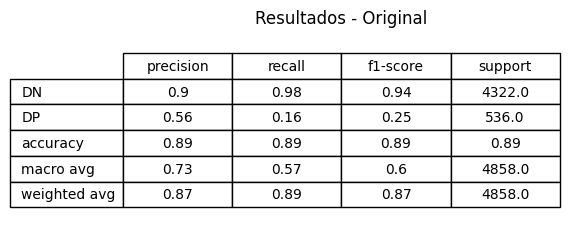

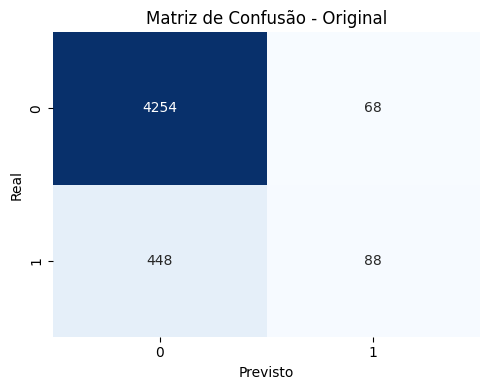

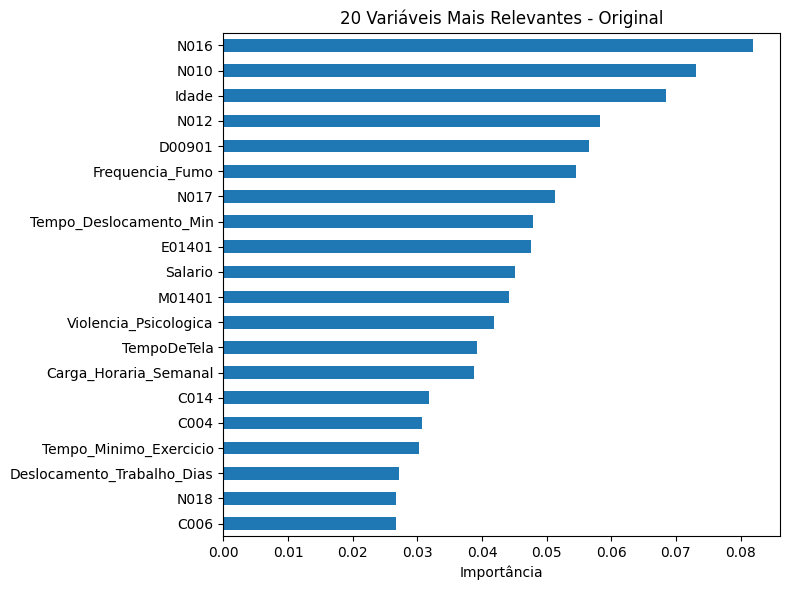

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

modelo_original = RandomForestClassifier(random_state=42)
f1_original = avaliar_modelo(modelo_original, X_treino, y_treino, X_teste, y_teste, "Original")


## Balanceamento pré-holdout

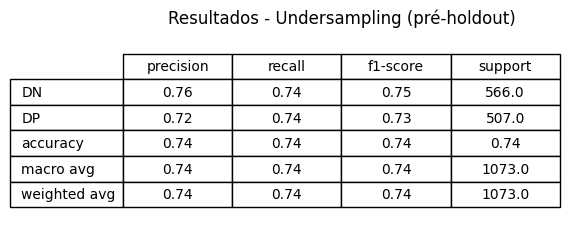

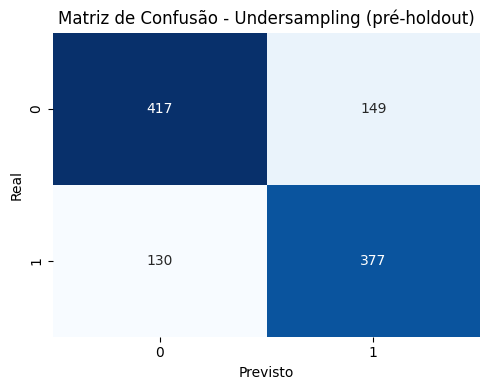

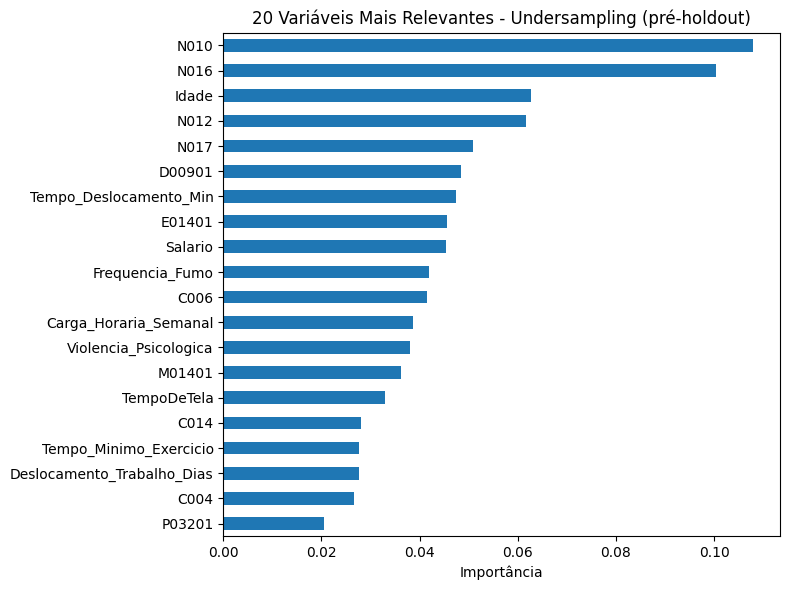

In [6]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

X_treino_rus, X_teste_rus, y_treino_rus, y_teste_rus = train_test_split(X_rus, y_rus, test_size=0.3, random_state=42)

modelo_under_pre_holdout = RandomForestClassifier(random_state=42)
f1_under = avaliar_modelo(modelo_under_pre_holdout, X_treino_rus, y_treino_rus, X_teste_rus, y_teste_rus, "Undersampling (pré-holdout)")


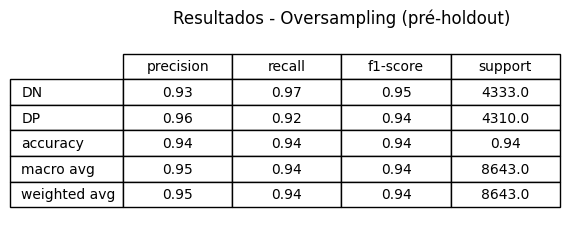

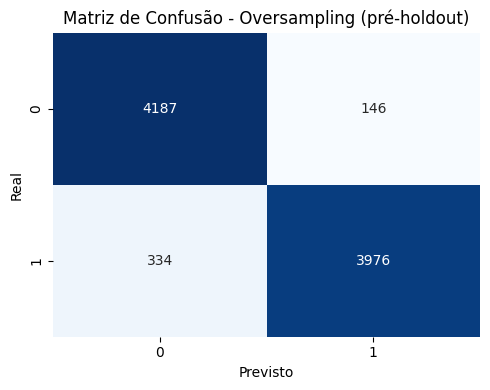

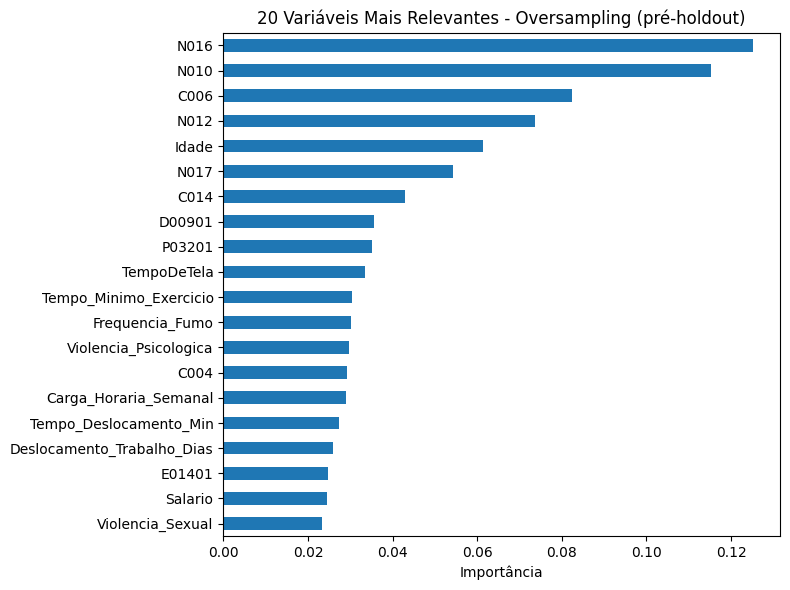

In [7]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

X_treino_smote, X_teste_smote, y_treino_smote, y_teste_smote = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)

modelo_over_pre_holdout = RandomForestClassifier(random_state=42)
f1_over = avaliar_modelo(modelo_over_pre_holdout, X_treino_smote, y_treino_smote, X_teste_smote, y_teste_smote, "Oversampling (pré-holdout)")


## Comparação Final

In [8]:
metricas = []
metricas.append(extrair_metricas(y_teste, modelo_original.predict(X_teste), "Original"))
metricas.append(extrair_metricas(y_teste_rus, modelo_under_pre_holdout.predict(X_teste_rus), "Undersampling (pré-holdout"))
metricas.append(extrair_metricas(y_teste_smote, modelo_over_pre_holdout.predict(X_teste_smote), "Oversampling (pré-holdout"))

df_resultados = pd.DataFrame(metricas).round(2)
display(df_resultados)

,Modelo,Accuracy,0_Precision,0_Recall,0_F1,1_Precision,1_Recall,1_F1,F1_Macro
0,Original,0.89,0.90,0.98,0.94,0.56,0.16,0.25,0.60
1,Undersampling (pré-holdout,0.74,0.76,0.74,0.75,0.72,0.74,0.73,0.74
2,Oversampling (pré-holdout,0.94,0.93,0.97,0.95,0.96,0.92,0.94,0.94
